Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32856 entries, 0 to 32855
Data columns (total 74 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   GLOBAL_ID                                                    32856 non-null  int64  
 1   SOURCE_FILE                                                  32856 non-null  object 
 2   WATERSHED                                                    32856 non-null  object 
 3   DATE_TIME_HEURE                                              32856 non-null  object 
 4   SAMPLE_ID_ÉCHANTILLON                                        32856 non-null  object 
 5   ALUMINUM TOTAL (µG/L)                                        22030 non-null  float64
 6   ANTIMONY TOTAL (µG/L)                                        19998 non-null  float64
 7   ARSENIC TOTAL (µG/L)                                   

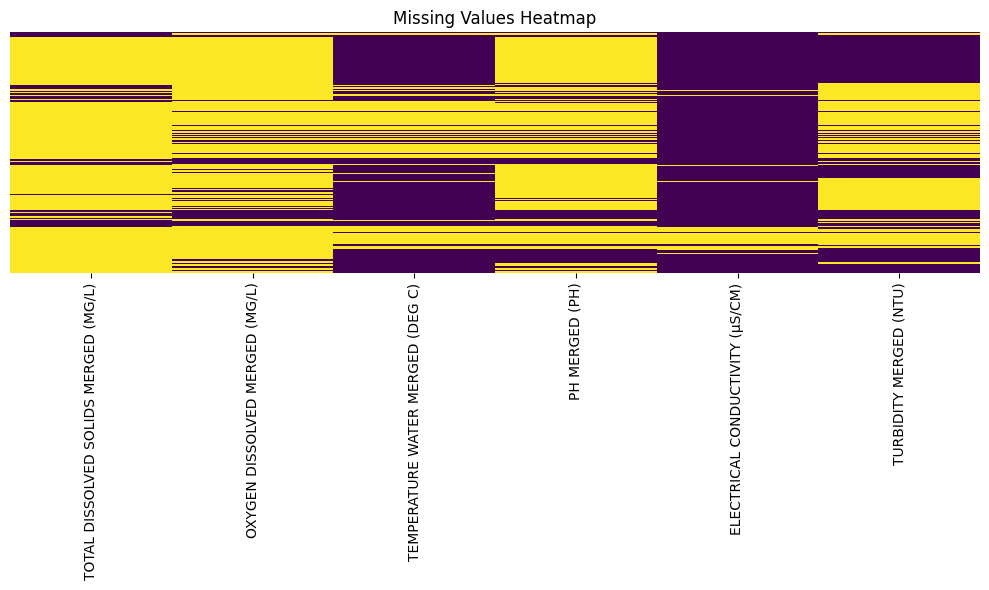


Feature Statistical Summary:
       TOTAL DISSOLVED SOLIDS MERGED (MG/L)  OXYGEN DISSOLVED MERGED (MG/L)  \
count                           5598.000000                     7487.000000   
mean                             244.857711                       11.485605   
std                              192.320959                       24.535347   
min                                5.231000                       -0.320000   
25%                              136.834250                        9.195000   
50%                              199.467000                       10.790000   
75%                              274.022500                       12.300000   
max                             1728.714000                     1200.000000   

       TEMPERATURE WATER MERGED (DEG C)  PH MERGED (PH)  \
count                      22131.000000     8571.000000   
mean                           8.120282        7.676306   
std                            7.035295        0.891099   
min                   

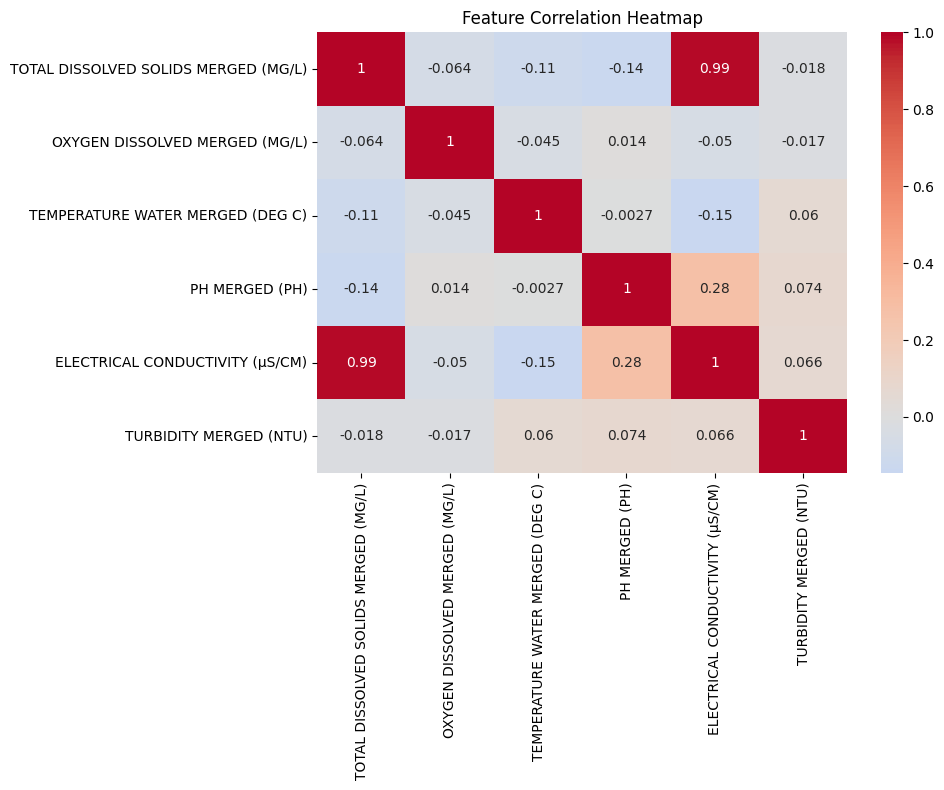

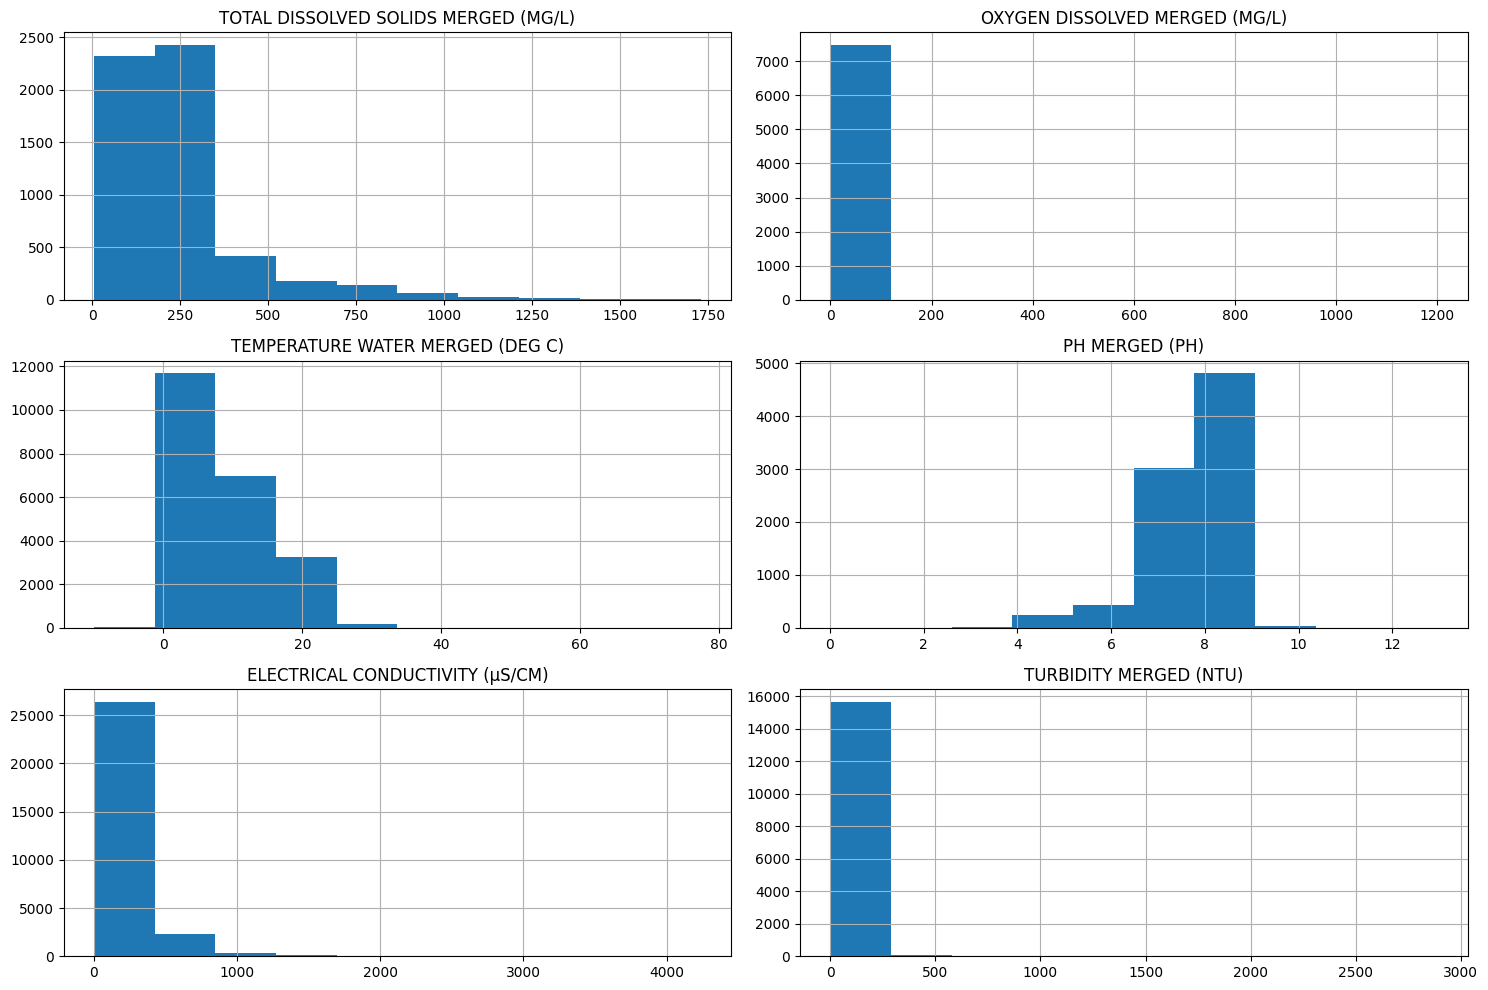

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Missing values after imputation:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    0
OXYGEN DISSOLVED MERGED (MG/L)          0
TEMPERATURE WATER MERGED (DEG C)        0
PH MERGED (PH)                          0
ELECTRICAL CONDUCTIVITY (µS/CM)         0
TURBIDITY MERGED (NTU)                  0
dtype: int64


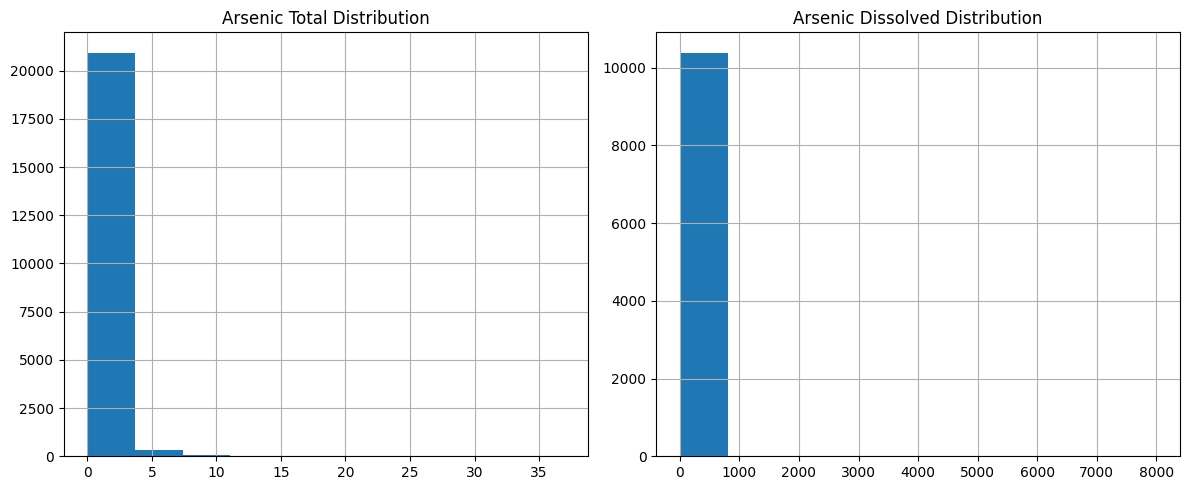

Data preparation completed successfully!

Scaled Features Shape: (32856, 6)
Arsenic Total Target Shape: (32856,)
Arsenic Dissolved Target Shape: (32856,)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
def load_and_prepare_data(file_path):
    # Read the CSV file
    df = pd.read_csv(file_path, low_memory=False)

    # Print basic information about the dataset
    print("Dataset Information:")
    print(df.info())

    # Show first few rows
    print("\nFirst 10 rows of the dataset:")
    print(df.head(10))

    # Select feature columns
    feature_columns = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'OXYGEN DISSOLVED MERGED (MG/L)',
        'TEMPERATURE WATER MERGED (DEG C)',
        'PH MERGED (PH)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TURBIDITY MERGED (NTU)'
    ]

    # Select target columns
    target_columns = [
        'ARSENIC TOTAL (µG/L)',
        'ARSENIC DISSOLVED (µG/L)'
    ]

    # Extract features and targets
    X = df[feature_columns]
    y_total = df['ARSENIC TOTAL (µG/L)']
    y_dissolved = df['ARSENIC DISSOLVED (µG/L)']

    return X, y_total, y_dissolved

# Step 2: Data Exploration and Preprocessing
def explore_and_preprocess_data(X, y_total, y_dissolved):
    # Check for missing values
    print("\nMissing values in features:")
    print(X.isnull().sum())

    # Visualize missing data
    plt.figure(figsize=(10, 6))
    sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.tight_layout()
    plt.show()

    # Basic statistical summary
    print("\nFeature Statistical Summary:")
    print(X.describe())

    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Histograms of features
    X.hist(figsize=(15, 10))
    plt.tight_layout()
    plt.show()

    # Advanced Missing Value Imputation
    # Use IterativeImputer (MICE - Multivariate Imputation by Chained Equations)
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=100, random_state=42),
        max_iter=10,
        random_state=42
    )

    # Impute missing values
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    # Verify imputation
    print("\nMissing values after imputation:")
    print(X_imputed.isnull().sum())

    # Scale features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_imputed),
        columns=X_imputed.columns,
        index=X_imputed.index
    )

    # Target variable distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    y_total.hist()
    plt.title('Arsenic Total Distribution')
    plt.subplot(1, 2, 2)
    y_dissolved.hist()
    plt.title('Arsenic Dissolved Distribution')
    plt.tight_layout()
    plt.show()

    return X_scaled, y_total, y_dissolved

# Main execution
if __name__ == '__main__':
    # Load the dataset
    X, y_total, y_dissolved = load_and_prepare_data('new_combined_water_quality_dataset_fixed.csv')

    # Explore and preprocess data
    X_scaled, y_total, y_dissolved = explore_and_preprocess_data(X, y_total, y_dissolved)

    print("Data preparation completed successfully!")
    print("\nScaled Features Shape:", X_scaled.shape)
    print("Arsenic Total Target Shape:", y_total.shape)
    print("Arsenic Dissolved Target Shape:", y_dissolved.shape)

Missing Value Analysis:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    27258
OXYGEN DISSOLVED MERGED (MG/L)          25369
TEMPERATURE WATER MERGED (DEG C)        10725
PH MERGED (PH)                          24285
ELECTRICAL CONDUCTIVITY (µS/CM)          3587
TURBIDITY MERGED (NTU)                  17107
dtype: int64

Missing Percentage:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    82.96
OXYGEN DISSOLVED MERGED (MG/L)          77.21
TEMPERATURE WATER MERGED (DEG C)        32.64
PH MERGED (PH)                          73.91
ELECTRICAL CONDUCTIVITY (µS/CM)         10.92
TURBIDITY MERGED (NTU)                  52.07
dtype: float64

Missing Values After Imputation:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    0
OXYGEN DISSOLVED MERGED (MG/L)          0
TEMPERATURE WATER MERGED (DEG C)        0
PH MERGED (PH)                          0
ELECTRICAL CONDUCTIVITY (µS/CM)         0
TURBIDITY MERGED (NTU)                  0
dtype: int64


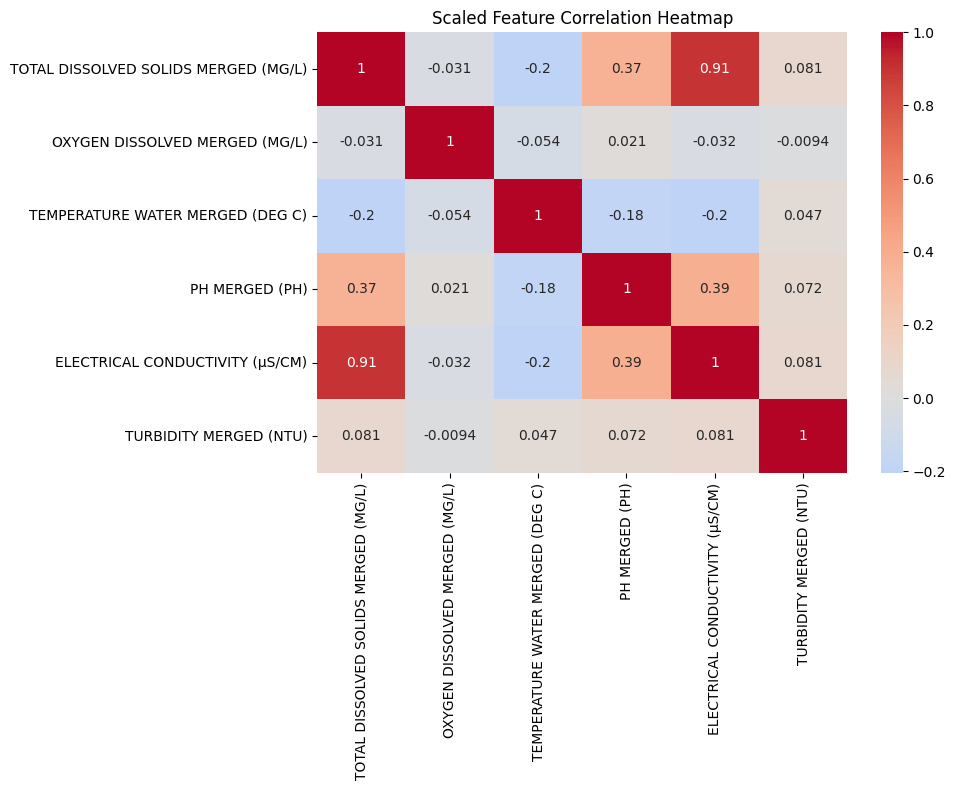

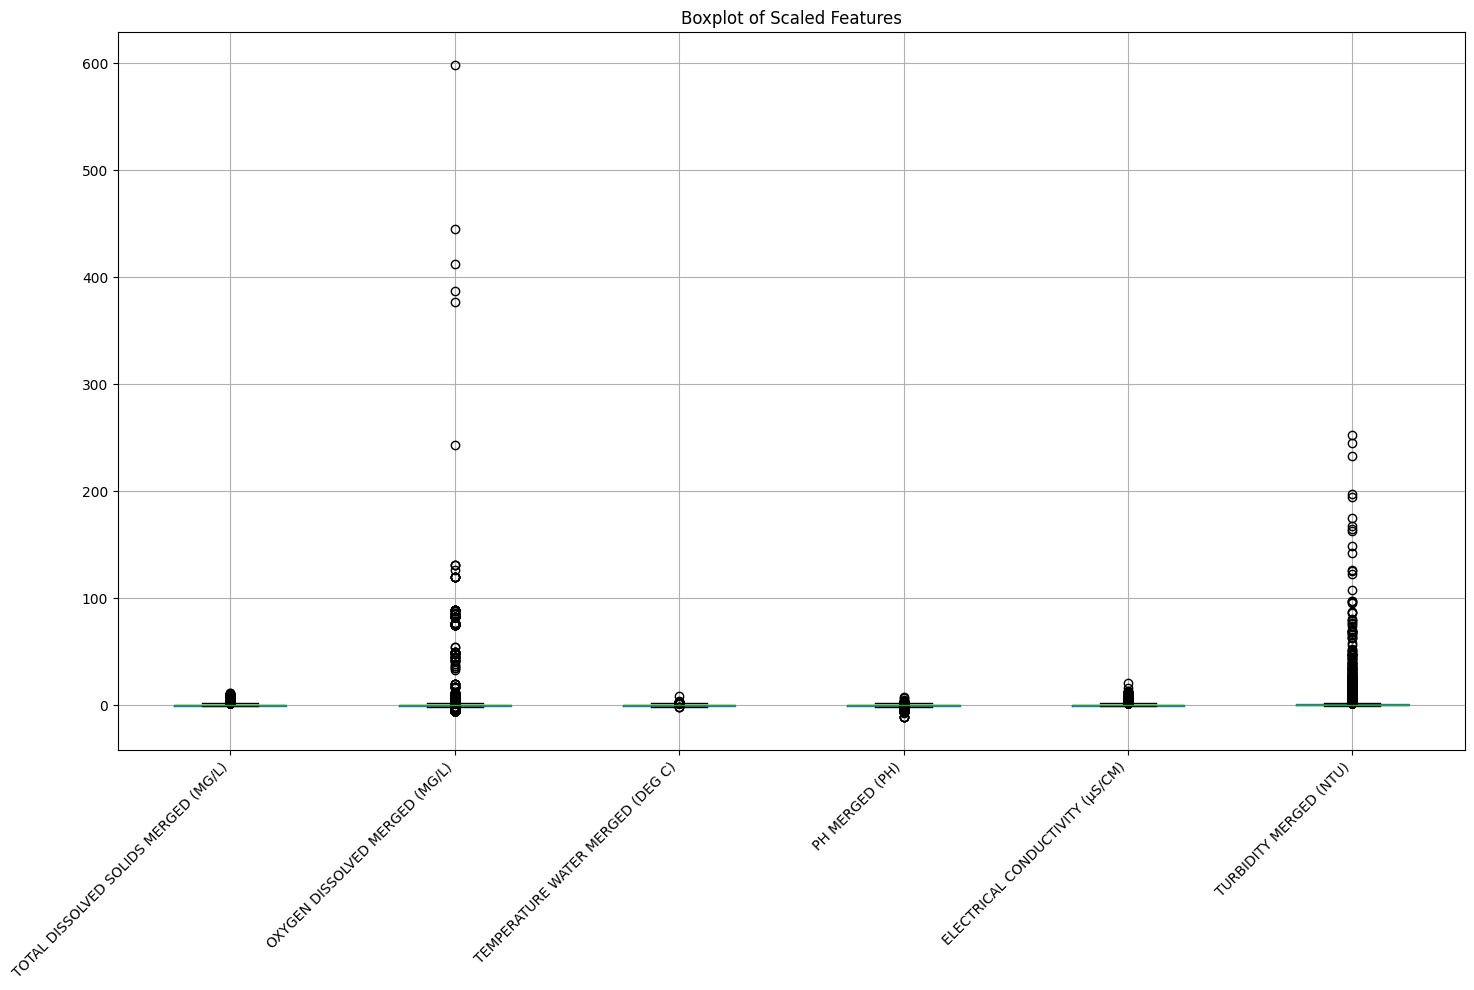

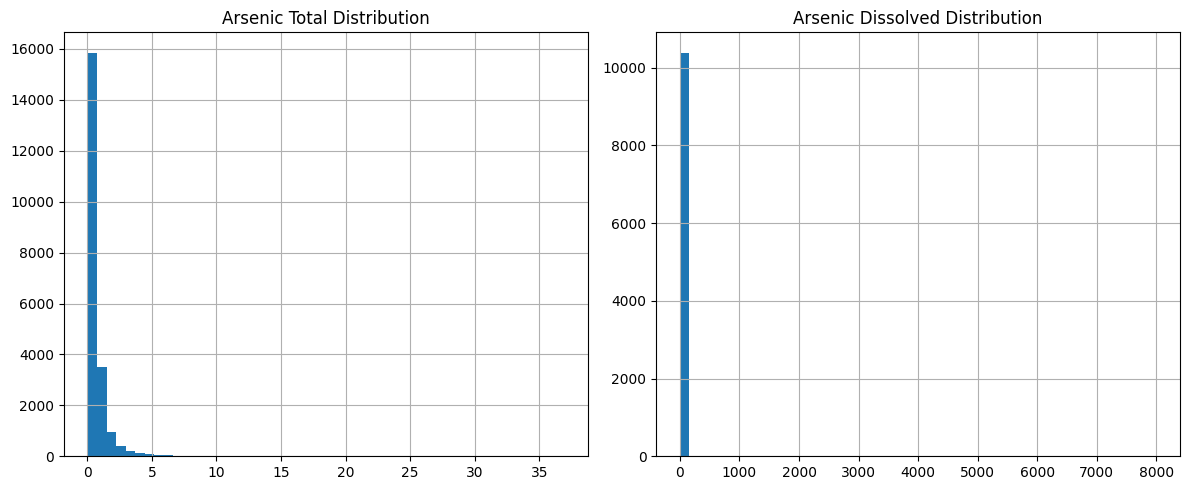


Processing Summary:
Scaled Features Shape: (32856, 6)
Arsenic Total Target Shape: (32856,)
Arsenic Dissolved Target Shape: (32856,)

Cleaned Data Summary:
Arsenic Total - Features Shape: (21344, 6)
Arsenic Total - Target Shape: (21344,)
Arsenic Dissolved - Features Shape: (10388, 6)
Arsenic Dissolved - Target Shape: (10388,)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

def advanced_data_preprocessing(file_path):
    # 1. Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # 2. Select specific features and targets
    feature_columns = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'OXYGEN DISSOLVED MERGED (MG/L)',
        'TEMPERATURE WATER MERGED (DEG C)',
        'PH MERGED (PH)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TURBIDITY MERGED (NTU)'
    ]

    target_columns = [
        'ARSENIC TOTAL (µG/L)',
        'ARSENIC DISSOLVED (µG/L)'
    ]

    # 3. Extract features and targets
    X = df[feature_columns].copy()
    y_total = df['ARSENIC TOTAL (µG/L)']
    y_dissolved = df['ARSENIC DISSOLVED (µG/L)']

    # 4. Detailed Missing Value Analysis
    print("Missing Value Analysis:")
    print(X.isnull().sum())
    print("\nMissing Percentage:")
    print((X.isnull().sum() / len(X) * 100).round(2))

    # 5. Advanced Imputation
    # Use KNN Imputer for missing value handling
    imputer = KNNImputer(n_neighbors=5, weights='uniform')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    # 6. Verify Imputation
    print("\nMissing Values After Imputation:")
    print(X_imputed.isnull().sum())

    # 7. Feature Scaling
    scaler = RobustScaler()  # More robust to outliers
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_imputed),
        columns=X_imputed.columns,
        index=X_imputed.index
    )

    # 8. Comprehensive Visualization
    # Correlation Heatmap
    plt.figure(figsize=(10, 8))
    correlation_matrix = X_scaled.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Scaled Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Boxplot to check for outliers
    plt.figure(figsize=(15, 10))
    X_scaled.boxplot()
    plt.title('Boxplot of Scaled Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 9. Target Variable Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    y_total.hist(bins=50)
    plt.title('Arsenic Total Distribution')
    plt.subplot(1, 2, 2)
    y_dissolved.hist(bins=50)
    plt.title('Arsenic Dissolved Distribution')
    plt.tight_layout()
    plt.show()

    return X_scaled, y_total, y_dissolved

# Main execution
if __name__ == '__main__':
    # Load and preprocess the dataset
    X_scaled, y_total, y_dissolved = advanced_data_preprocessing('new_combined_water_quality_dataset_fixed.csv')

    print("\nProcessing Summary:")
    print("Scaled Features Shape:", X_scaled.shape)
    print("Arsenic Total Target Shape:", y_total.shape)
    print("Arsenic Dissolved Target Shape:", y_dissolved.shape)

    # Additional Data Cleaning for Targets
    # Remove rows with NaN in target variables
    mask_total = ~y_total.isna()
    mask_dissolved = ~y_dissolved.isna()

    X_total = X_scaled[mask_total]
    y_total_clean = y_total[mask_total]

    X_dissolved = X_scaled[mask_dissolved]
    y_dissolved_clean = y_dissolved[mask_dissolved]

    print("\nCleaned Data Summary:")
    print("Arsenic Total - Features Shape:", X_total.shape)
    print("Arsenic Total - Target Shape:", y_total_clean.shape)
    print("Arsenic Dissolved - Features Shape:", X_dissolved.shape)
    print("Arsenic Dissolved - Target Shape:", y_dissolved_clean.shape)

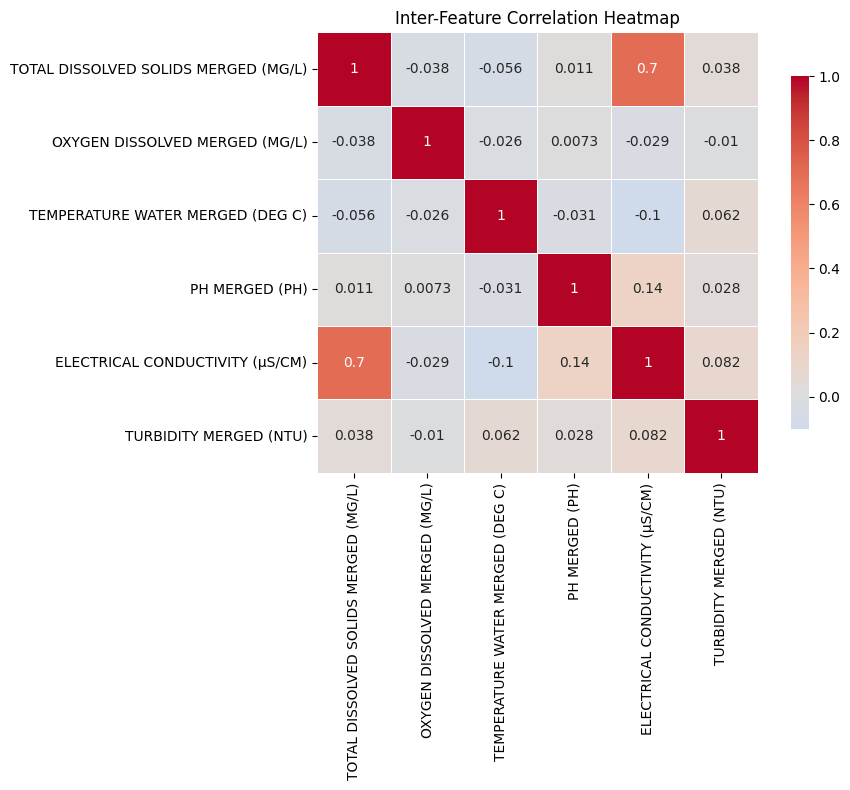


Inter-Feature Correlation Matrix:
                                      TOTAL DISSOLVED SOLIDS MERGED (MG/L)  \
TOTAL DISSOLVED SOLIDS MERGED (MG/L)                              1.000000   
OXYGEN DISSOLVED MERGED (MG/L)                                   -0.038002   
TEMPERATURE WATER MERGED (DEG C)                                 -0.056384   
PH MERGED (PH)                                                    0.011303   
ELECTRICAL CONDUCTIVITY (µS/CM)                                   0.695035   
TURBIDITY MERGED (NTU)                                            0.038148   

                                      OXYGEN DISSOLVED MERGED (MG/L)  \
TOTAL DISSOLVED SOLIDS MERGED (MG/L)                       -0.038002   
OXYGEN DISSOLVED MERGED (MG/L)                              1.000000   
TEMPERATURE WATER MERGED (DEG C)                           -0.025901   
PH MERGED (PH)                                              0.007297   
ELECTRICAL CONDUCTIVITY (µS/CM)                           

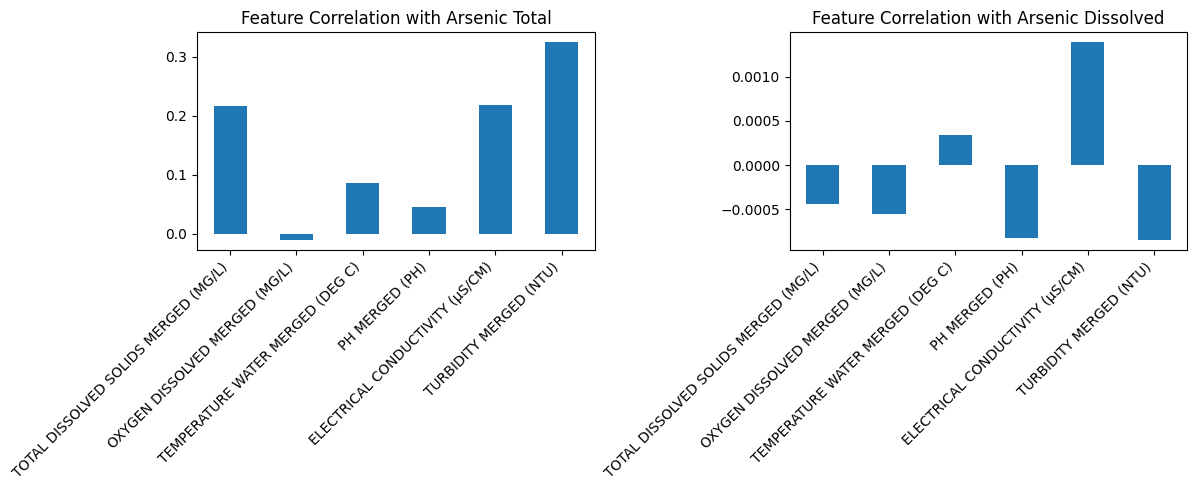

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

def advanced_correlation_analysis(file_path):
    # 1. Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # 2. Select specific features and targets
    feature_columns = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'OXYGEN DISSOLVED MERGED (MG/L)',
        'TEMPERATURE WATER MERGED (DEG C)',
        'PH MERGED (PH)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TURBIDITY MERGED (NTU)'
    ]

    target_columns = [
        'ARSENIC TOTAL (µG/L)',
        'ARSENIC DISSOLVED (µG/L)'
    ]

    # 3. Extract features and targets
    X = df[feature_columns].copy()
    y_total = df['ARSENIC TOTAL (µG/L)']
    y_dissolved = df['ARSENIC DISSOLVED (µG/L)']

    # 4. Handle Missing Values (Simple median imputation for correlation analysis)
    X_imputed = X.fillna(X.median())

    # 5. Inter-Feature Correlation Matrix
    correlation_matrix = X_imputed.corr()

    # Visualization of Feature Correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Inter-Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # 6. Correlation with Target Variables
    # Prepare data for correlation analysis
    X_for_correlation = X_imputed.copy()

    # Correlation with Arsenic Total
    total_correlations = pd.Series(index=feature_columns)
    for feature in feature_columns:
        valid_mask = ~(y_total.isna() | X_for_correlation[feature].isna())
        if valid_mask.sum() > 0:
            total_correlations[feature] = np.corrcoef(
                X_for_correlation.loc[valid_mask, feature],
                y_total[valid_mask]
            )[0, 1]

    # Correlation with Arsenic Dissolved
    dissolved_correlations = pd.Series(index=feature_columns)
    for feature in feature_columns:
        valid_mask = ~(y_dissolved.isna() | X_for_correlation[feature].isna())
        if valid_mask.sum() > 0:
            dissolved_correlations[feature] = np.corrcoef(
                X_for_correlation.loc[valid_mask, feature],
                y_dissolved[valid_mask]
            )[0, 1]

    # 7. Mutual Information (Non-linear relationship measure)
    X_for_mi = X_imputed.copy()
    mi_total = mutual_info_regression(X_for_mi, y_total.fillna(y_total.median()))
    mi_dissolved = mutual_info_regression(X_for_mi, y_dissolved.fillna(y_dissolved.median()))

    # Print Results
    print("\nInter-Feature Correlation Matrix:")
    print(correlation_matrix)

    print("\nCorrelation with Arsenic Total:")
    print(total_correlations)

    print("\nCorrelation with Arsenic Dissolved:")
    print(dissolved_correlations)

    print("\nMutual Information with Arsenic Total:")
    for feature, mi in zip(feature_columns, mi_total):
        print(f"{feature}: {mi}")

    print("\nMutual Information with Arsenic Dissolved:")
    for feature, mi in zip(feature_columns, mi_dissolved):
        print(f"{feature}: {mi}")

    # Visualization of Target Correlations
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    total_correlations.plot(kind='bar')
    plt.title('Feature Correlation with Arsenic Total')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.subplot(1, 2, 2)
    dissolved_correlations.plot(kind='bar')
    plt.title('Feature Correlation with Arsenic Dissolved')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()

# Main execution
if __name__ == '__main__':
    advanced_correlation_analysis('new_combined_water_quality_dataset_fixed.csv')


--- Arsenic Total Prediction ---

Random Forest (Total Arsenic) Model Evaluation:
Mean Squared Error: 0.7444785465692854
Mean Absolute Error: 0.40732319028308667
R-squared Score: 0.30212319172713176
Cross-validation MSE scores: [0.29676669 0.98313465 0.78030309 1.52675488 1.52818775]
Average CV MSE: 1.0230294099840826


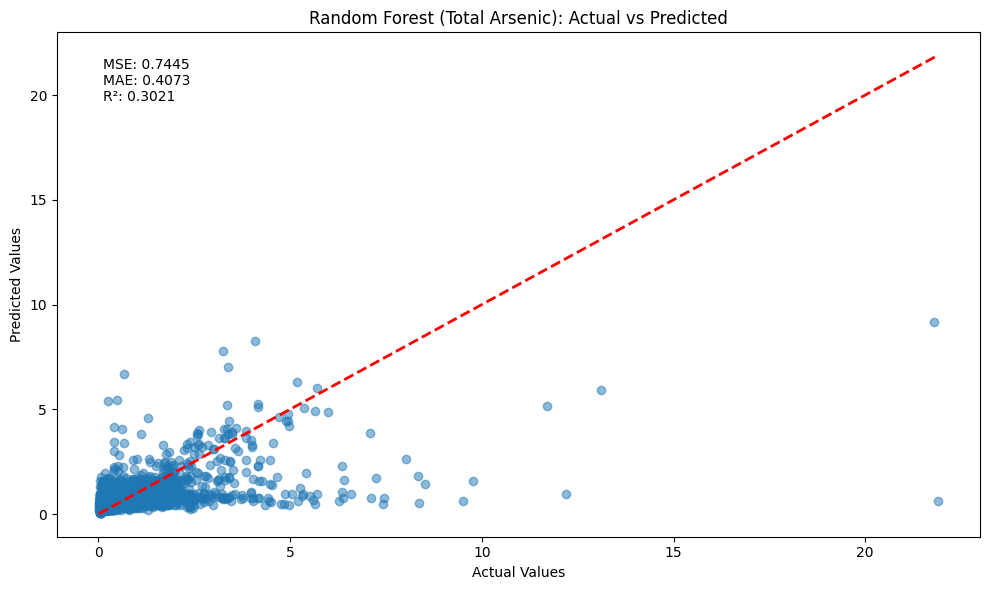


MLP (Total Arsenic) Model Evaluation:
Mean Squared Error: 0.7960022953327012
Mean Absolute Error: 0.4521903518495263
R-squared Score: 0.2538246484004445
Cross-validation MSE scores: [0.31363572 1.01309589 0.8677378  1.58020697 1.51203519]
Average CV MSE: 1.057342313505325


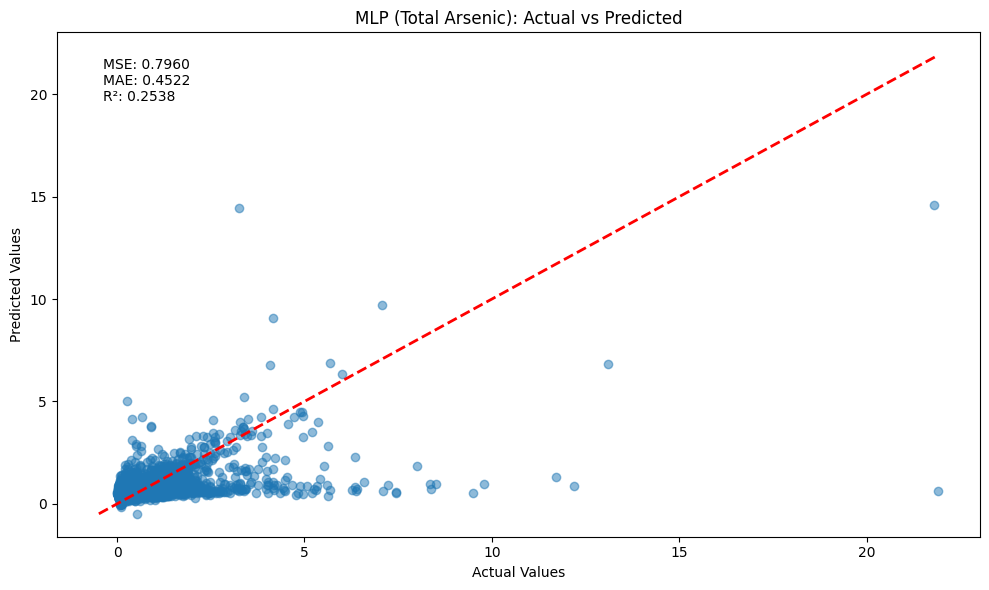


--- Arsenic Dissolved Prediction ---

Random Forest (Dissolved Arsenic) Model Evaluation:
Mean Squared Error: 0.1655161580642767
Mean Absolute Error: 0.21422472838236553
R-squared Score: 0.5055713661952201
Cross-validation MSE scores: [1.53848004e-01 3.07959092e+04 6.99737172e+02 3.02061321e-01
 4.82674609e-01]
Average CV MSE: 6299.316983102954


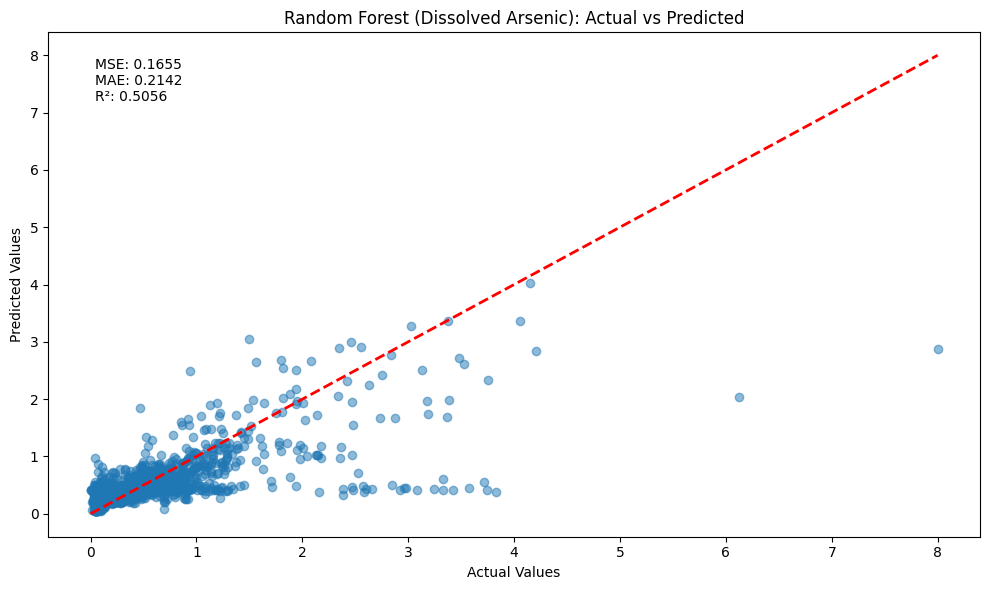


MLP (Dissolved Arsenic) Model Evaluation:
Mean Squared Error: 0.2851743254298024
Mean Absolute Error: 0.3578593562060819
R-squared Score: 0.14812938043365254
Cross-validation MSE scores: [1.00837037e-01 3.07949902e+04 3.68789059e-01 3.95302420e-01
 5.20280265e-01]
Average CV MSE: 6159.27507544965


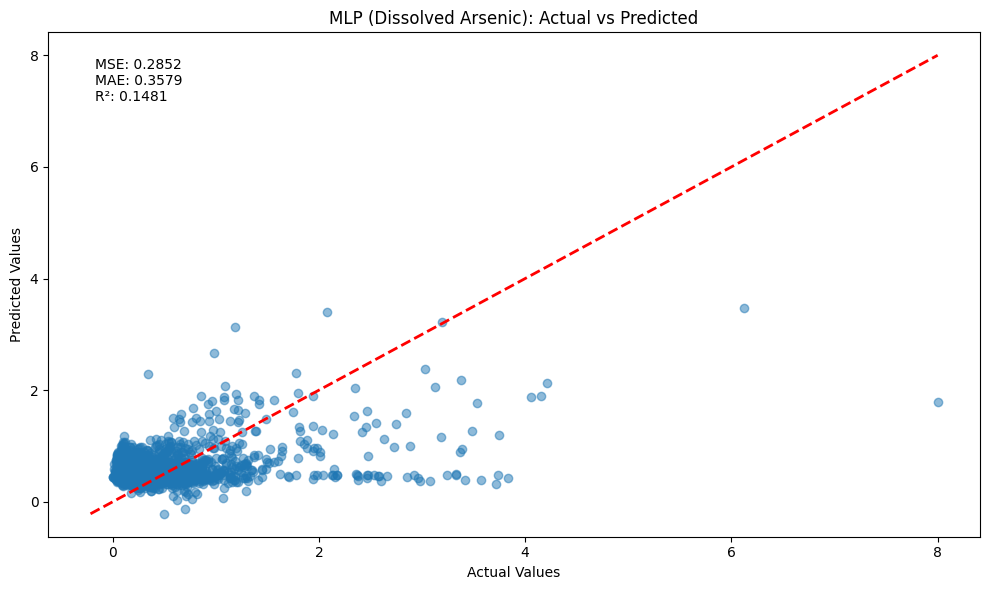

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def prepare_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Select features and targets
    feature_columns = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'OXYGEN DISSOLVED MERGED (MG/L)',
        'TEMPERATURE WATER MERGED (DEG C)',
        'PH MERGED (PH)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TURBIDITY MERGED (NTU)'
    ]

    # Prepare data for Arsenic Total
    X_total = df[feature_columns]
    y_total = df['ARSENIC TOTAL (µG/L)']

    # Remove rows with NaN in target
    mask_total = ~y_total.isna()
    X_total = X_total[mask_total]
    y_total = y_total[mask_total]

    # Prepare data for Arsenic Dissolved
    X_dissolved = df[feature_columns]
    y_dissolved = df['ARSENIC DISSOLVED (µG/L)']

    # Remove rows with NaN in target
    mask_dissolved = ~y_dissolved.isna()
    X_dissolved = X_dissolved[mask_dissolved]
    y_dissolved = y_dissolved[mask_dissolved]

    return X_total, y_total, X_dissolved, y_dissolved

def create_model_pipeline(model_type='rf'):
    # Create preprocessing steps
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Choose model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10
        )
    elif model_type == 'mlp':
        model = MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        )
    else:
        raise ValueError("Invalid model type. Choose 'rf' or 'mlp'.")

    # Full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', numeric_transformer),
        ('regressor', model)
    ])

    return pipeline

def plot_actual_vs_predicted(y_true, y_pred, title):
    """
    Create an actual vs. predicted plot with additional diagnostic information
    """
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs predicted
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Perfect prediction line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'{title}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

    # Add text with performance metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    plt.text(0.05, 0.95,
             f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
             transform=plt.gca().transAxes,
             verticalalignment='top')

    plt.tight_layout()
    plt.show()

def evaluate_model(X, y, model_pipeline, model_name):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit the model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = model_pipeline.predict(X_test)

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(
        model_pipeline, X, y,
        cv=5, scoring='neg_mean_squared_error'
    )

    print(f"\n{model_name} Model Evaluation:")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R-squared Score: {r2}")
    print("Cross-validation MSE scores:", -cv_scores)
    print("Average CV MSE:", -cv_scores.mean())

    # Plot Actual vs Predicted
    plot_actual_vs_predicted(y_test, y_pred, model_name)

    return model_pipeline

def main():
    # Load and prepare data
    X_total, y_total, X_dissolved, y_dissolved = prepare_data(
        'new_combined_water_quality_dataset_fixed.csv'
    )

    # Arsenic Total Modeling
    print("\n--- Arsenic Total Prediction ---")
    rf_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('rf'),
        "Random Forest (Total Arsenic)"
    )

    mlp_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('mlp'),
        "MLP (Total Arsenic)"
    )

    # Arsenic Dissolved Modeling
    print("\n--- Arsenic Dissolved Prediction ---")
    rf_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('rf'),
        "Random Forest (Dissolved Arsenic)"
    )

    mlp_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('mlp'),
        "MLP (Dissolved Arsenic)"
    )

if __name__ == '__main__':
    main()

1. MISSING VALUES ANALYSIS:
                                      Total Missing  Missing Percentage
TOTAL DISSOLVED SOLIDS MERGED (MG/L)          27258               82.96
OXYGEN DISSOLVED MERGED (MG/L)                25369               77.21
PH MERGED (PH)                                24285               73.91
ARSENIC DISSOLVED (µG/L)                      22468               68.38
TURBIDITY MERGED (NTU)                        17107               52.07
ARSENIC TOTAL (µG/L)                          11512               35.04
TEMPERATURE WATER MERGED (DEG C)              10725               32.64
ELECTRICAL CONDUCTIVITY (µS/CM)                3587               10.92

2. DATA COMPLETENESS:
Rows with complete Total Arsenic data: 2327 (7.08%)
Rows with complete Dissolved Arsenic data: 2297 (6.99%)


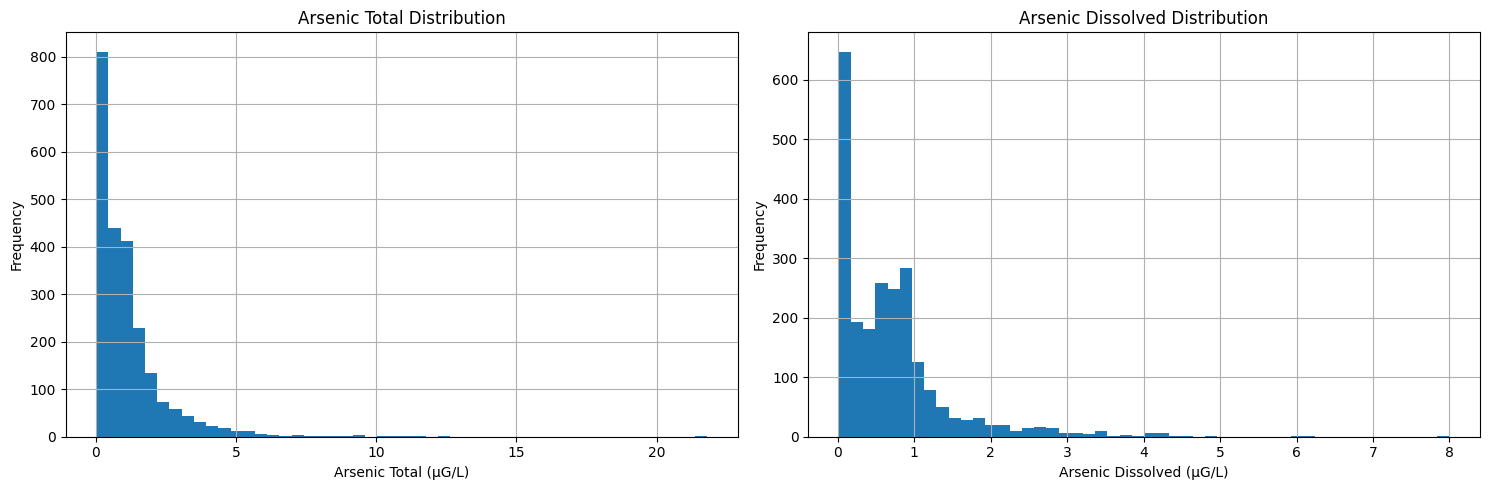

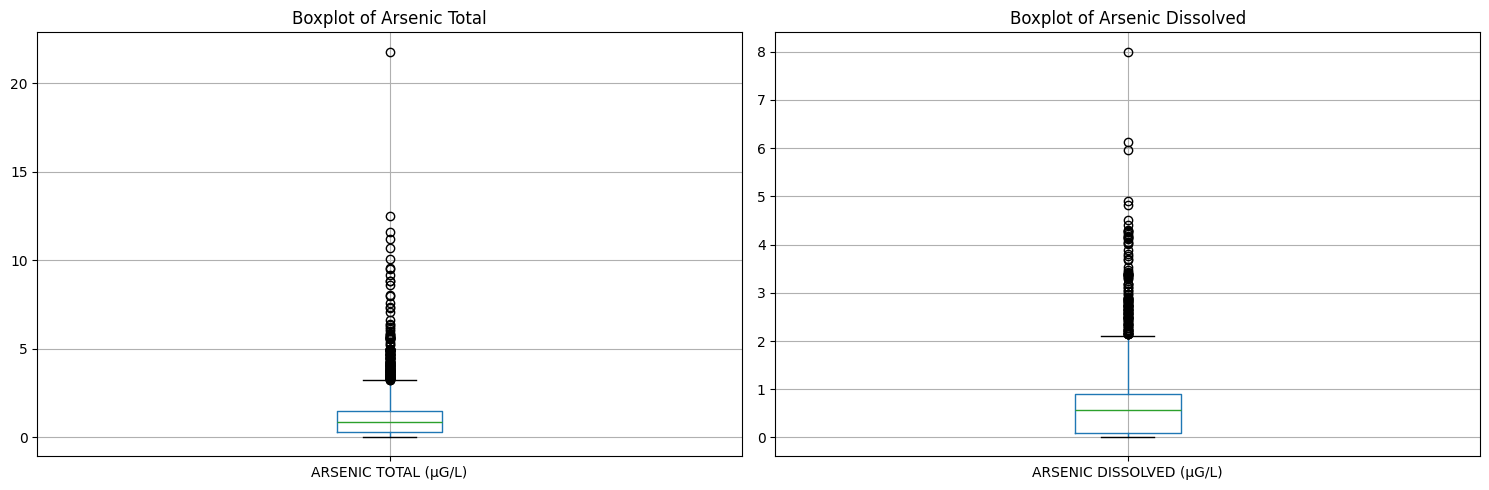


5. DESCRIPTIVE STATISTICS (COMPLETE DATA):

Total Arsenic:
count    2327.000000
mean        1.133782
std         1.369058
min         0.010000
25%         0.280000
50%         0.840000
75%         1.460000
max        21.800000
Name: ARSENIC TOTAL (µG/L), dtype: float64

Dissolved Arsenic:
count    2297.000000
mean        0.695342
std         0.749986
min         0.010000
25%         0.100000
50%         0.570000
75%         0.900000
max         8.000000
Name: ARSENIC DISSOLVED (µG/L), dtype: float64

6. CORRELATION ANALYSIS (COMPLETE DATA):

Total Arsenic Correlations:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    0.386081
OXYGEN DISSOLVED MERGED (MG/L)         -0.300296
TEMPERATURE WATER MERGED (DEG C)        0.326779
PH MERGED (PH)                         -0.032748
ELECTRICAL CONDUCTIVITY (µS/CM)         0.381590
TURBIDITY MERGED (NTU)                  0.538140
Name: ARSENIC TOTAL (µG/L), dtype: float64

Dissolved Arsenic Correlations:
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    0.577130
OXYG

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def comprehensive_dataset_investigation(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Feature and target columns
    feature_columns = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'OXYGEN DISSOLVED MERGED (MG/L)',
        'TEMPERATURE WATER MERGED (DEG C)',
        'PH MERGED (PH)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TURBIDITY MERGED (NTU)'
    ]

    target_columns = [
        'ARSENIC TOTAL (µG/L)',
        'ARSENIC DISSOLVED (µG/L)'
    ]

    # 1. Missing Values Analysis
    print("1. MISSING VALUES ANALYSIS:")
    # Create a DataFrame for missing value percentages
    missing_df = pd.DataFrame({
        'Total Missing': df[feature_columns + target_columns].isnull().sum(),
        'Missing Percentage': (df[feature_columns + target_columns].isnull().sum() / len(df) * 100).round(2)
    }).sort_values('Missing Percentage', ascending=False)
    print(missing_df)

    # 2. Data Completeness Investigation
    print("\n2. DATA COMPLETENESS:")
    # Find rows with complete data for specific targets and features
    complete_total = df.dropna(subset=feature_columns + ['ARSENIC TOTAL (µG/L)'])
    complete_dissolved = df.dropna(subset=feature_columns + ['ARSENIC DISSOLVED (µG/L)'])

    print(f"Rows with complete Total Arsenic data: {len(complete_total)} ({len(complete_total)/len(df)*100:.2f}%)")
    print(f"Rows with complete Dissolved Arsenic data: {len(complete_dissolved)} ({len(complete_dissolved)/len(df)*100:.2f}%)")

    # 3. Target Variable Distribution
    plt.figure(figsize=(15,5))

    plt.subplot(1, 2, 1)
    complete_total['ARSENIC TOTAL (µG/L)'].hist(bins=50)
    plt.title('Arsenic Total Distribution')
    plt.xlabel('Arsenic Total (µG/L)')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    complete_dissolved['ARSENIC DISSOLVED (µG/L)'].hist(bins=50)
    plt.title('Arsenic Dissolved Distribution')
    plt.xlabel('Arsenic Dissolved (µG/L)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # 4. Outlier Detection
    plt.figure(figsize=(15,5))

    plt.subplot(1, 2, 1)
    complete_total.boxplot(column='ARSENIC TOTAL (µG/L)')
    plt.title('Boxplot of Arsenic Total')

    plt.subplot(1, 2, 2)
    complete_dissolved.boxplot(column='ARSENIC DISSOLVED (µG/L)')
    plt.title('Boxplot of Arsenic Dissolved')

    plt.tight_layout()
    plt.show()

    # 5. Descriptive Statistics for Complete Data
    print("\n5. DESCRIPTIVE STATISTICS (COMPLETE DATA):")
    print("\nTotal Arsenic:")
    print(complete_total['ARSENIC TOTAL (µG/L)'].describe())

    print("\nDissolved Arsenic:")
    print(complete_dissolved['ARSENIC DISSOLVED (µG/L)'].describe())

    # 6. Correlation with Complete Data
    print("\n6. CORRELATION ANALYSIS (COMPLETE DATA):")
    # Correlation for Total Arsenic
    print("\nTotal Arsenic Correlations:")
    correlation_total = complete_total[feature_columns + ['ARSENIC TOTAL (µG/L)']].corr()['ARSENIC TOTAL (µG/L)'][:-1]
    print(correlation_total)

    # Correlation for Dissolved Arsenic
    print("\nDissolved Arsenic Correlations:")
    correlation_dissolved = complete_dissolved[feature_columns + ['ARSENIC DISSOLVED (µG/L)']].corr()['ARSENIC DISSOLVED (µG/L)'][:-1]
    print(correlation_dissolved)

def main():
    comprehensive_dataset_investigation('new_combined_water_quality_dataset_fixed.csv')

if __name__ == '__main__':
    main()



Data Preparation Summary:
Total Arsenic - Samples: 2366
Dissolved Arsenic - Samples: 3598

--- Arsenic Total Prediction ---

Random Forest (Total Arsenic) Model Evaluation:
Mean Squared Error: 0.35311555568625386
Mean Absolute Error: 0.33564717261903604
R-squared Score: 0.7337389139296626
Cross-validation MSE scores: [0.68244481 1.34692143 0.72925719 1.47822042 0.79644961]
Average CV MSE: 1.0066586938497533


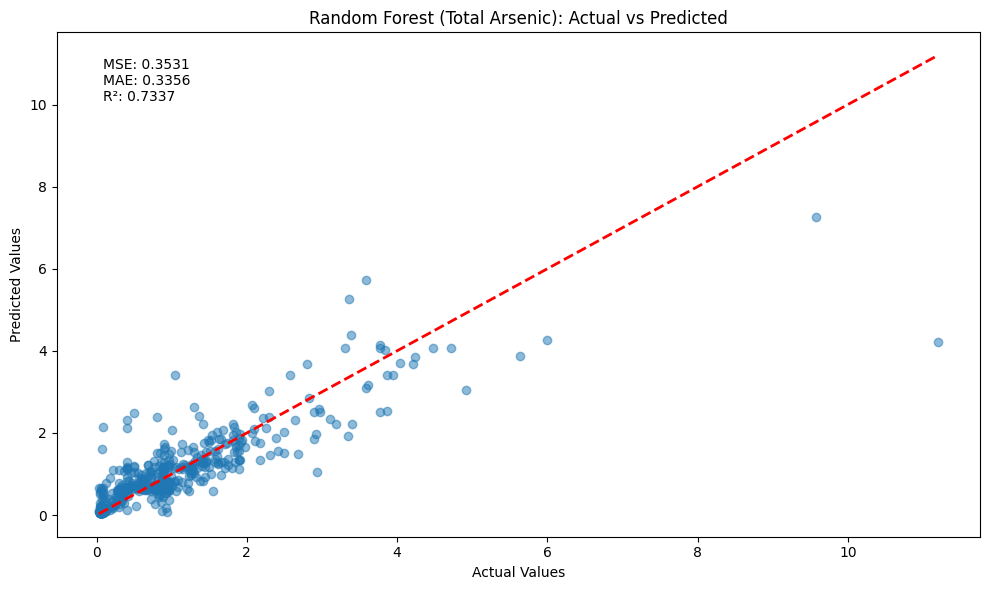


MLP (Total Arsenic) Model Evaluation:
Mean Squared Error: 0.4058619180605641
Mean Absolute Error: 0.43993793405212844
R-squared Score: 0.6939663706194441
Cross-validation MSE scores: [0.65363654 1.44242851 0.92184151 1.10052455 0.78655868]
Average CV MSE: 0.9809979586158534


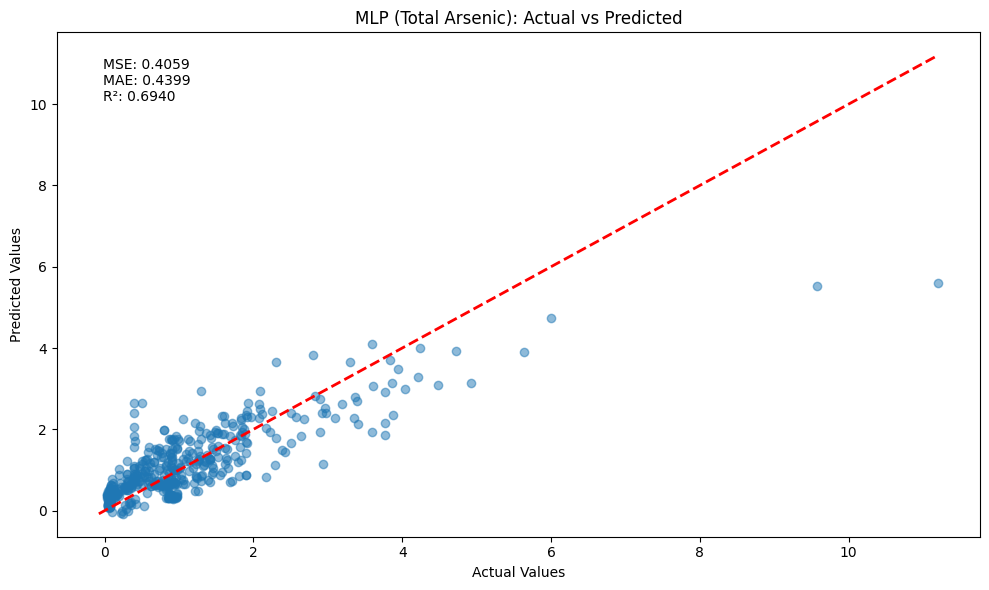


--- Arsenic Dissolved Prediction ---

Random Forest (Dissolved Arsenic) Model Evaluation:
Mean Squared Error: 0.10601695555019583
Mean Absolute Error: 0.21879806015880415
R-squared Score: 0.7485046783046743
Cross-validation MSE scores: [0.18226765 0.07917149 0.40420018 0.29001337 0.13429239]
Average CV MSE: 0.2179890139186599


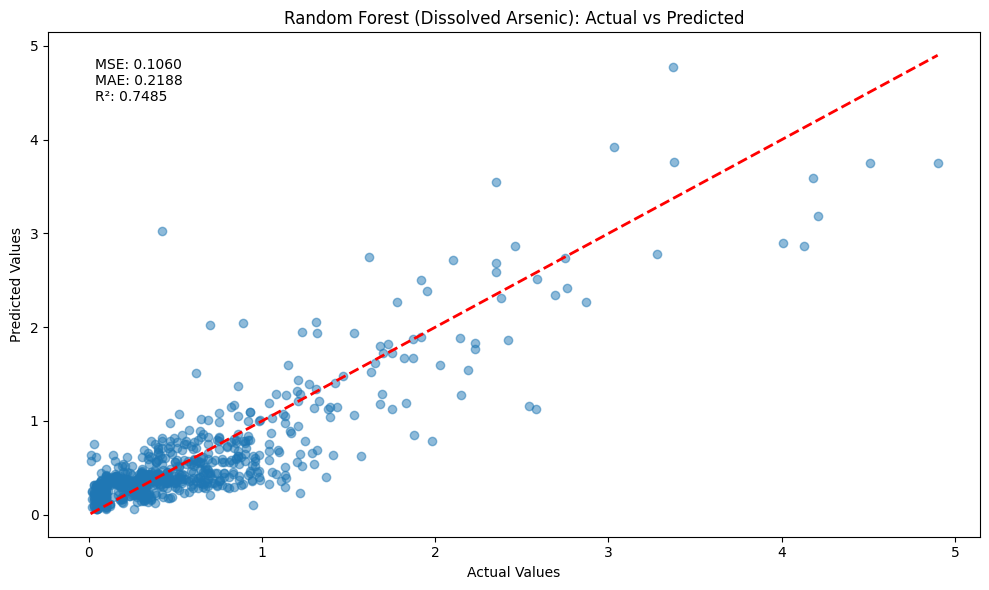


MLP (Dissolved Arsenic) Model Evaluation:
Mean Squared Error: 0.11707588132871428
Mean Absolute Error: 0.2406930182482586
R-squared Score: 0.7222704964057572
Cross-validation MSE scores: [0.16915115 0.06490003 0.2896702  0.29106309 0.10456675]
Average CV MSE: 0.18387024534407118


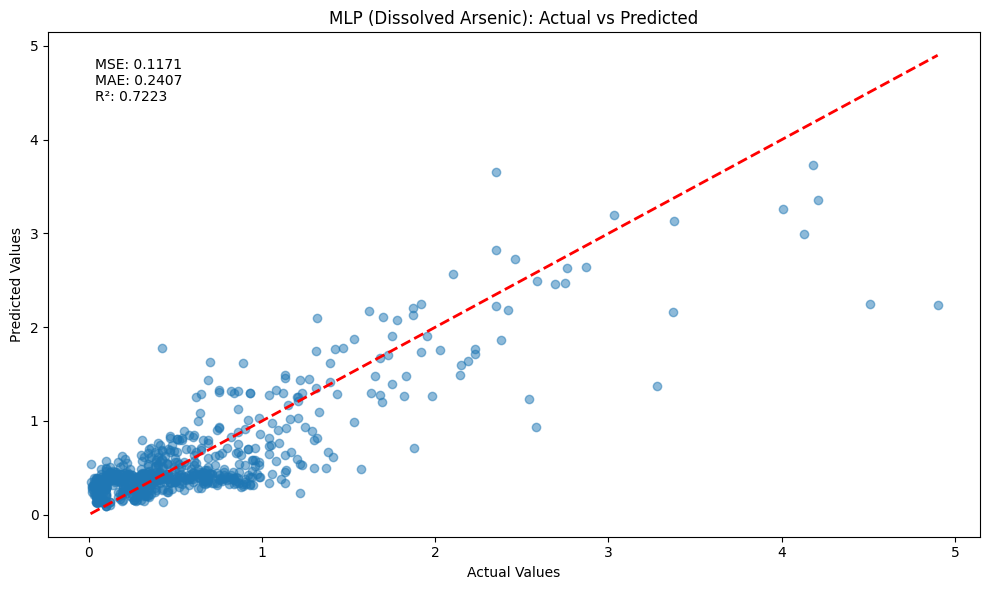

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

def prepare_selective_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Identify features with stronger correlations
    features_total = [
        'TURBIDITY MERGED (NTU)',
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    features_dissolved = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    # Find rows with complete data for both target and selected features
    def get_complete_data(feature_list, target_column):
        # Columns to check for completeness
        cols_to_check = feature_list + [target_column]

        # Drop rows with any NaN in the selected columns
        complete_df = df.dropna(subset=cols_to_check)

        # Extract features and target
        X = complete_df[feature_list]
        y = complete_df[target_column]

        return X, y

    # Prepare data for Total and Dissolved Arsenic
    X_total, y_total = get_complete_data(features_total, 'ARSENIC TOTAL (µG/L)')
    X_dissolved, y_dissolved = get_complete_data(features_dissolved, 'ARSENIC DISSOLVED (µG/L)')

    print("\nData Preparation Summary:")
    print(f"Total Arsenic - Samples: {len(X_total)}")
    print(f"Dissolved Arsenic - Samples: {len(X_dissolved)}")

    return X_total, y_total, X_dissolved, y_dissolved

def create_model_pipeline(model_type='rf', log_transform=True):
    # Preprocessing steps
    preprocessing_steps = [
        ('scaler', StandardScaler())
    ]

    # Choose model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10
        )
    elif model_type == 'mlp':
        model = MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        )
    else:
        raise ValueError("Invalid model type. Choose 'rf' or 'mlp'.")

    # Full pipeline
    pipeline = Pipeline(steps=preprocessing_steps + [('regressor', model)])

    return pipeline

def plot_actual_vs_predicted(y_true, y_pred, title):
    """
    Create an actual vs. predicted plot with additional diagnostic information
    """
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs predicted
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Perfect prediction line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'{title}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

    # Add text with performance metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    plt.text(0.05, 0.95,
             f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
             transform=plt.gca().transAxes,
             verticalalignment='top')

    plt.tight_layout()
    plt.show()

def evaluate_model(X, y, model_pipeline, model_name):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit the model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = model_pipeline.predict(X_test)

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(
        model_pipeline, X, y,
        cv=5, scoring='neg_mean_squared_error'
    )

    print(f"\n{model_name} Model Evaluation:")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R-squared Score: {r2}")
    print("Cross-validation MSE scores:", -cv_scores)
    print("Average CV MSE:", -cv_scores.mean())

    # Plot Actual vs Predicted
    plot_actual_vs_predicted(y_test, y_pred, model_name)

    return model_pipeline

def main():
    # Load and prepare selective data
    X_total, y_total, X_dissolved, y_dissolved = prepare_selective_data(
        'new_combined_water_quality_dataset_fixed.csv'
    )

    # Arsenic Total Modeling
    print("\n--- Arsenic Total Prediction ---")
    rf_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('rf'),
        "Random Forest (Total Arsenic)"
    )

    mlp_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('mlp'),
        "MLP (Total Arsenic)"
    )

    # Arsenic Dissolved Modeling
    print("\n--- Arsenic Dissolved Prediction ---")
    rf_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('rf'),
        "Random Forest (Dissolved Arsenic)"
    )

    mlp_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('mlp'),
        "MLP (Dissolved Arsenic)"
    )

if __name__ == '__main__':
    main()


Data Preparation Summary:
Total Arsenic - Samples: 2366
Dissolved Arsenic - Samples: 3598

--- Arsenic Total Prediction ---

Random Forest (Total Arsenic) Model Evaluation:
Training MSE: 0.18990313702998635
Testing MSE: 0.35311555568625386
Training R²: 0.9046330488352475
Testing R²: 0.7337389139296626
Cross-validation MSE scores: [0.68244481 1.34692143 0.72925719 1.47822042 0.79644961]
Average CV MSE: 1.0066586938497533


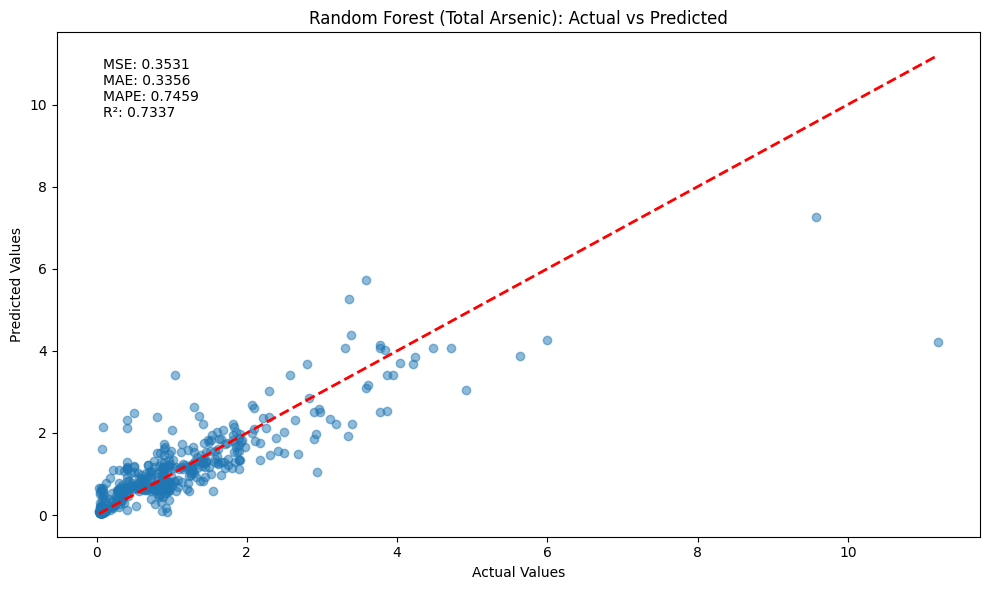

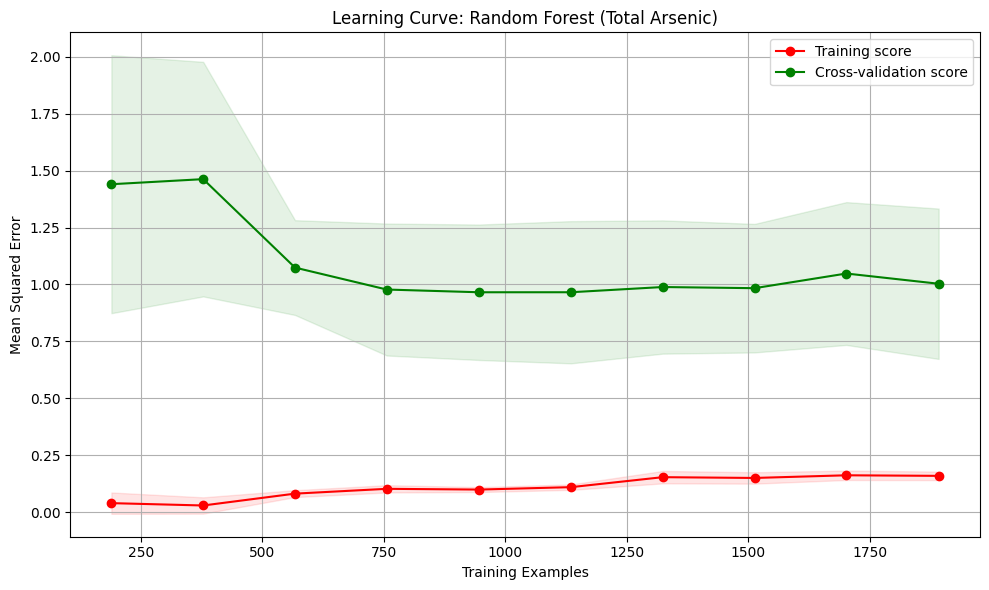


Model saved to models/Random_Forest_(Total_Arsenic).joblib

MLP (Total Arsenic) Model Evaluation:
Training MSE: 0.8408468641278206
Testing MSE: 0.4058619180605641
Training R²: 0.5777373503016384
Testing R²: 0.6939663706194441
Cross-validation MSE scores: [0.65363654 1.44242851 0.92184151 1.10052455 0.78655868]
Average CV MSE: 0.9809979586158534


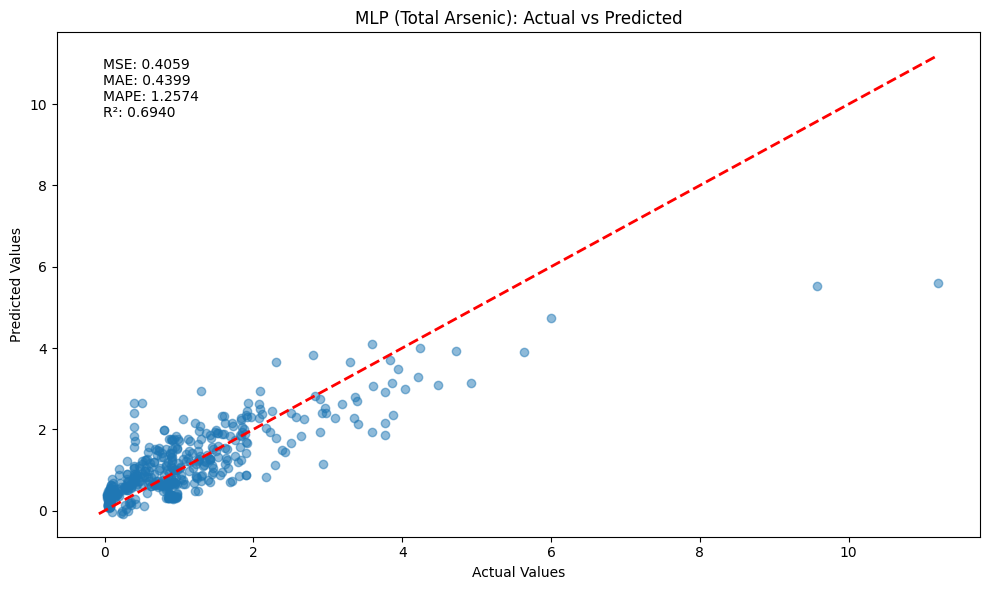

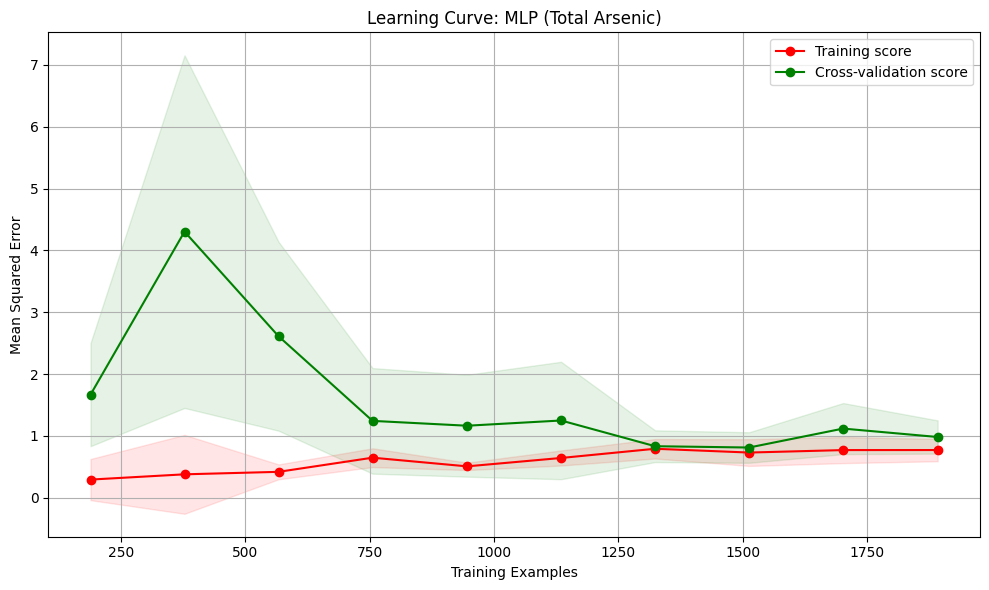


Model saved to models/MLP_(Total_Arsenic).joblib

--- Arsenic Dissolved Prediction ---

Random Forest (Dissolved Arsenic) Model Evaluation:
Training MSE: 0.04749568319519356
Testing MSE: 0.10601695555019583
Training R²: 0.883202710226926
Testing R²: 0.7485046783046743
Cross-validation MSE scores: [0.18226765 0.07917149 0.40420018 0.29001337 0.13429239]
Average CV MSE: 0.2179890139186599


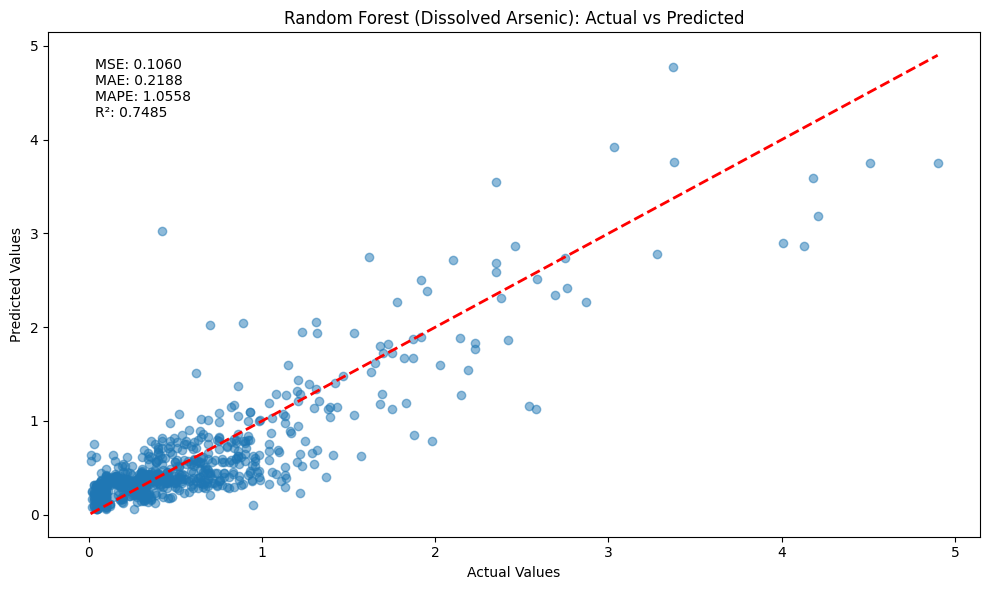

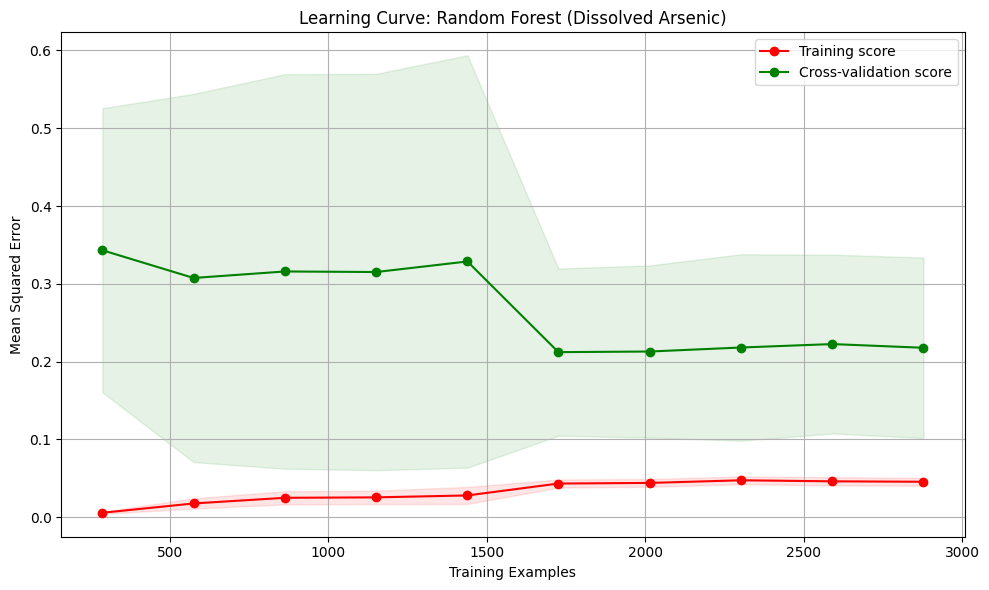


Model saved to models/Random_Forest_(Dissolved_Arsenic).joblib

MLP (Dissolved Arsenic) Model Evaluation:
Training MSE: 0.14372379072149746
Testing MSE: 0.11707588132871428
Training R²: 0.6465668434919547
Testing R²: 0.7222704964057572
Cross-validation MSE scores: [0.16915115 0.06490003 0.2896702  0.29106309 0.10456675]
Average CV MSE: 0.18387024534407118


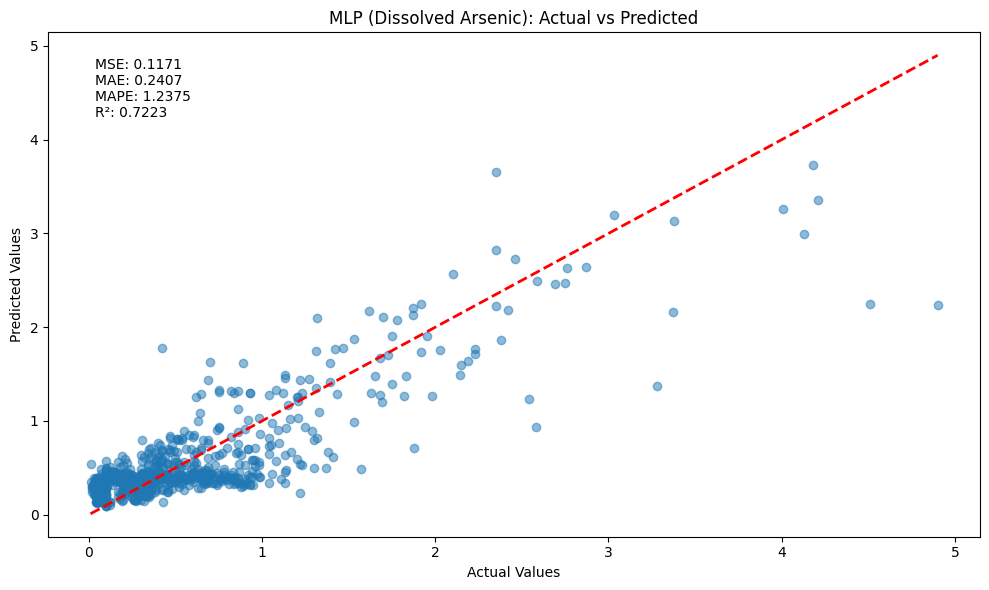

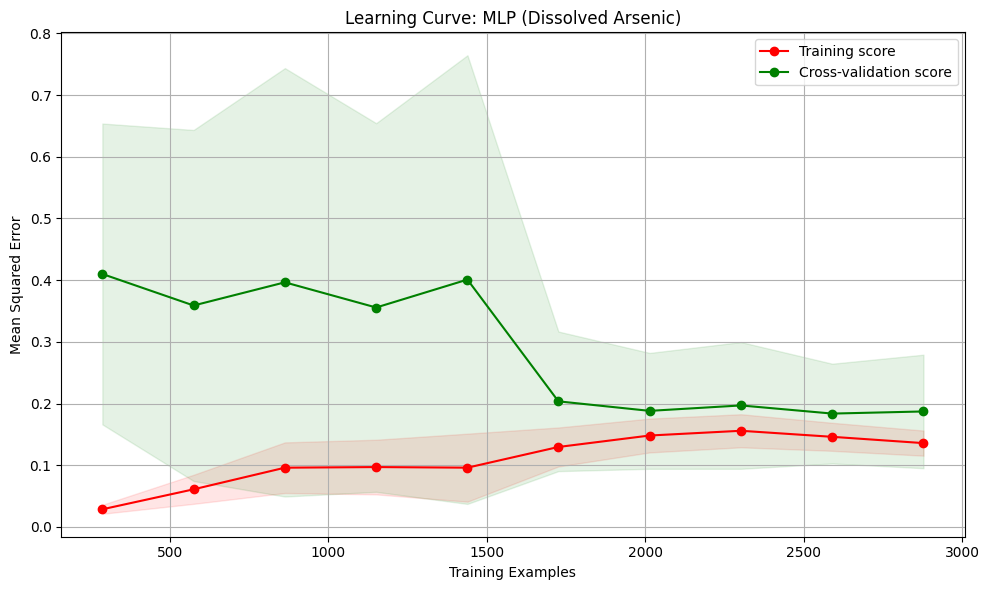


Model saved to models/MLP_(Dissolved_Arsenic).joblib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

def plot_learning_curve(estimator, X, y, title):
    """
    Generate learning curve to diagnose bias and variance
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error'
    )

    # Convert to positive MSE
    train_scores = -train_scores
    test_scores = -test_scores

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Squared Error')

    # Plot learning curves
    plt.grid()
    plt.fill_between(train_sizes,
                     train_mean - train_std,
                     train_mean + train_std,
                     alpha=0.1, color="r")
    plt.fill_between(train_sizes,
                     test_mean - test_std,
                     test_mean + test_std,
                     alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def prepare_selective_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Identify features with stronger correlations
    features_total = [
        'TURBIDITY MERGED (NTU)',
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    features_dissolved = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    # Find rows with complete data for both target and selected features
    def get_complete_data(feature_list, target_column):
        # Columns to check for completeness
        cols_to_check = feature_list + [target_column]

        # Drop rows with any NaN in the selected columns
        complete_df = df.dropna(subset=cols_to_check)

        # Extract features and target
        X = complete_df[feature_list]
        y = complete_df[target_column]

        return X, y

    # Prepare data for Total and Dissolved Arsenic
    X_total, y_total = get_complete_data(features_total, 'ARSENIC TOTAL (µG/L)')
    X_dissolved, y_dissolved = get_complete_data(features_dissolved, 'ARSENIC DISSOLVED (µG/L)')

    print("\nData Preparation Summary:")
    print(f"Total Arsenic - Samples: {len(X_total)}")
    print(f"Dissolved Arsenic - Samples: {len(X_dissolved)}")

    return X_total, y_total, X_dissolved, y_dissolved

def create_model_pipeline(model_type='rf'):
    # Preprocessing steps
    preprocessing_steps = [
        ('scaler', StandardScaler())
    ]

    # Choose model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10
        )
    elif model_type == 'mlp':
        model = MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        )
    else:
        raise ValueError("Invalid model type. Choose 'rf' or 'mlp'.")

    # Full pipeline
    pipeline = Pipeline(steps=preprocessing_steps + [('regressor', model)])

    return pipeline

def plot_actual_vs_predicted(y_true, y_pred, title):
    """
    Create an actual vs. predicted plot with additional diagnostic information
    """
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs predicted
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Perfect prediction line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'{title}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

    # Add text with performance metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    plt.text(0.05, 0.95,
             f'MSE: {mse:.4f}\nMAE: {mae:.4f}\n'\
             f'MAPE: {mape:.4f}\nR²: {r2:.4f}',
             transform=plt.gca().transAxes,
             verticalalignment='top')

    plt.tight_layout()
    plt.show()

def evaluate_and_save_model(X, y, model_pipeline, model_name, save_dir='models'):
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit the model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    # Evaluation metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Cross-validation
    cv_scores = cross_val_score(
        model_pipeline, X, y,
        cv=5, scoring='neg_mean_squared_error'
    )

    # Print evaluation metrics
    print(f"\n{model_name} Model Evaluation:")
    print(f"Training MSE: {train_mse}")
    print(f"Testing MSE: {test_mse}")
    print(f"Training R²: {train_r2}")
    print(f"Testing R²: {test_r2}")
    print("Cross-validation MSE scores:", -cv_scores)
    print("Average CV MSE:", -cv_scores.mean())

    # Plot actual vs predicted
    plot_actual_vs_predicted(y_test, y_test_pred, model_name)

    # Plot learning curve
    plot_learning_curve(model_pipeline, X, y, model_name)

    # Save model
    model_filename = os.path.join(save_dir, f'{model_name.replace(" ", "_")}.joblib')
    joblib.dump(model_pipeline, model_filename)
    print(f"\nModel saved to {model_filename}")

    return model_pipeline

def main():
    # Load and prepare selective data
    X_total, y_total, X_dissolved, y_dissolved = prepare_selective_data(
        'new_combined_water_quality_dataset_fixed.csv'
    )

    # Arsenic Total Modeling
    print("\n--- Arsenic Total Prediction ---")
    rf_total = evaluate_and_save_model(
        X_total, y_total,
        create_model_pipeline('rf'),
        "Random Forest (Total Arsenic)"
    )

    mlp_total = evaluate_and_save_model(
        X_total, y_total,
        create_model_pipeline('mlp'),
        "MLP (Total Arsenic)"
    )

    # Arsenic Dissolved Modeling
    print("\n--- Arsenic Dissolved Prediction ---")
    rf_dissolved = evaluate_and_save_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('rf'),
        "Random Forest (Dissolved Arsenic)"
    )

    mlp_dissolved = evaluate_and_save_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('mlp'),
        "MLP (Dissolved Arsenic)"
    )

if __name__ == '__main__':
    main()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

def prepare_selective_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Identify features with stronger correlations
    features_total = [
        'TURBIDITY MERGED (NTU)',
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    features_dissolved = [
        'TOTAL DISSOLVED SOLIDS MERGED (MG/L)',
        'ELECTRICAL CONDUCTIVITY (µS/CM)',
        'TEMPERATURE WATER MERGED (DEG C)'
    ]

    # Find rows with complete data for both target and selected features
    def get_complete_data(feature_list, target_column):
        # Columns to check for completeness
        cols_to_check = feature_list + [target_column]

        # Drop rows with any NaN in the selected columns
        complete_df = df.dropna(subset=cols_to_check)

        # Extract features and target
        X = complete_df[feature_list]
        y = complete_df[target_column]

        return X, y

    # Prepare data for Total and Dissolved Arsenic
    X_total, y_total = get_complete_data(features_total, 'ARSENIC TOTAL (µG/L)')
    X_dissolved, y_dissolved = get_complete_data(features_dissolved, 'ARSENIC DISSOLVED (µG/L)')

    print("\nData Preparation Summary:")
    print(f"Total Arsenic - Samples: {len(X_total)}")
    print(f"Dissolved Arsenic - Samples: {len(X_dissolved)}")

    return X_total, y_total, X_dissolved, y_dissolved

def create_model_pipeline(model_type='rf', log_transform=True):
    # Preprocessing steps
    preprocessing_steps = [
        ('scaler', StandardScaler())
    ]

    # Choose model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10
        )
    elif model_type == 'mlp':
        model = MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        )
    else:
        raise ValueError("Invalid model type. Choose 'rf' or 'mlp'.")

    # Full pipeline
    pipeline = Pipeline(steps=preprocessing_steps + [('regressor', model)])

    return pipeline

def plot_actual_vs_predicted(y_true, y_pred, title):
    """
    Create an actual vs. predicted plot with additional diagnostic information
    """
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs predicted
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Perfect prediction line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'{title}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

    # Add text with performance metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    plt.text(0.05, 0.95,
             f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
             transform=plt.gca().transAxes,
             verticalalignment='top')

    plt.tight_layout()
    plt.show()

def evaluate_model(X, y, model_pipeline, model_name):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit the model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = model_pipeline.predict(X_test)

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(
        model_pipeline, X, y,
        cv=5, scoring='neg_mean_squared_error'
    )

    print(f"\n{model_name} Model Evaluation:")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R-squared Score: {r2}")
    print("Cross-validation MSE scores:", -cv_scores)
    print("Average CV MSE:", -cv_scores.mean())

    # Plot Actual vs Predicted
    plot_actual_vs_predicted(y_test, y_pred, model_name)

    return model_pipeline

def main():
    # Load and prepare selective data
    X_total, y_total, X_dissolved, y_dissolved = prepare_selective_data(
        'new_combined_water_quality_dataset_fixed.csv'
    )

    # Arsenic Total Modeling
    print("\n--- Arsenic Total Prediction ---")
    rf_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('rf'),
        "Random Forest (Total Arsenic)"
    )

    mlp_total = evaluate_model(
        X_total, y_total,
        create_model_pipeline('mlp'),
        "MLP (Total Arsenic)"
    )

    # Arsenic Dissolved Modeling
    print("\n--- Arsenic Dissolved Prediction ---")
    rf_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('rf'),
        "Random Forest (Dissolved Arsenic)"
    )

    mlp_dissolved = evaluate_model(
        X_dissolved, y_dissolved,
        create_model_pipeline('mlp'),
        "MLP (Dissolved Arsenic)"
    )

if __name__ == '__main__':
    main()

Missing values before imputation:
ARSENIC DISSOLVED (µG/L)                22468
ELECTRICAL CONDUCTIVITY (µS/CM)          3587
PH MERGED (PH)                          24285
TEMPERATURE WATER MERGED (DEG C)        10725
OXYGEN DISSOLVED MERGED (MG/L)          25369
TOTAL DISSOLVED SOLIDS MERGED (MG/L)    27258
dtype: int64
Total rows: 32856


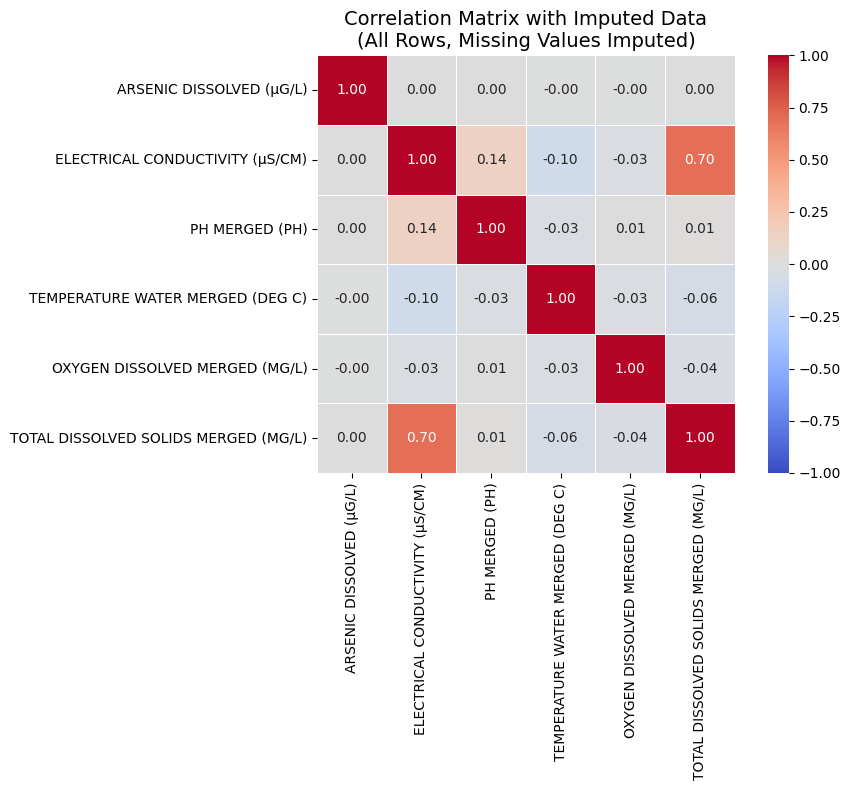


Complete rows (no missing values): 2536 out of 32856 (7.7%)


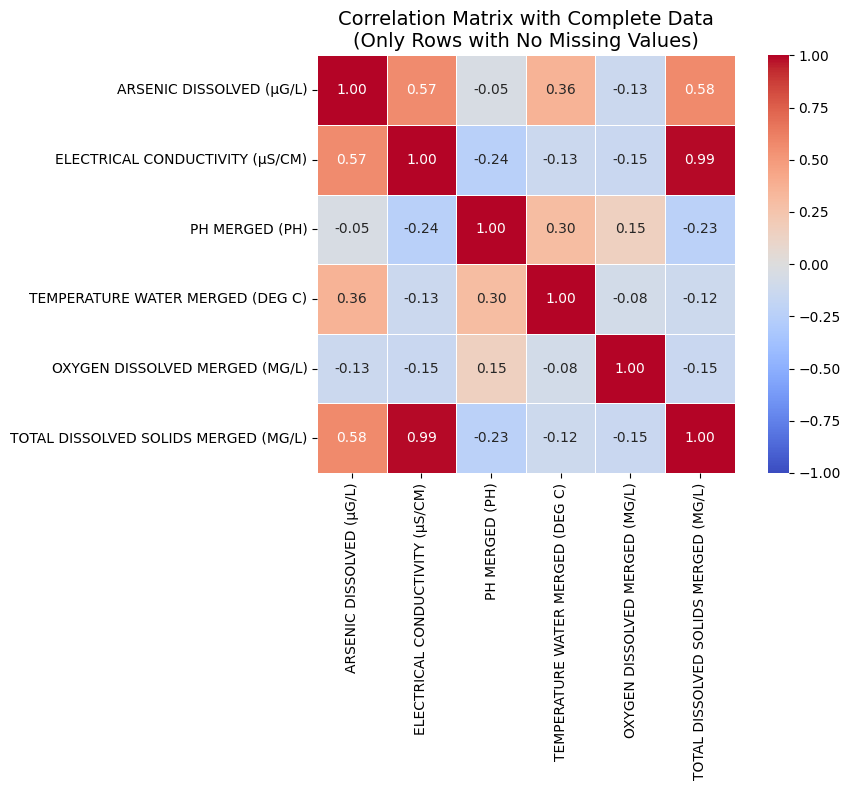


Comparison of correlation values with Arsenic Dissolved:
                                      Imputed Data  Complete Data  Difference
TOTAL DISSOLVED SOLIDS MERGED (MG/L)      0.000730       0.575186    0.574456
ELECTRICAL CONDUCTIVITY (µS/CM)           0.004638       0.568396    0.563758
TEMPERATURE WATER MERGED (DEG C)         -0.000088       0.361507    0.361594
OXYGEN DISSOLVED MERGED (MG/L)           -0.000258      -0.130054   -0.129796
PH MERGED (PH)                            0.001028      -0.045275   -0.046303


<Figure size 1200x600 with 0 Axes>

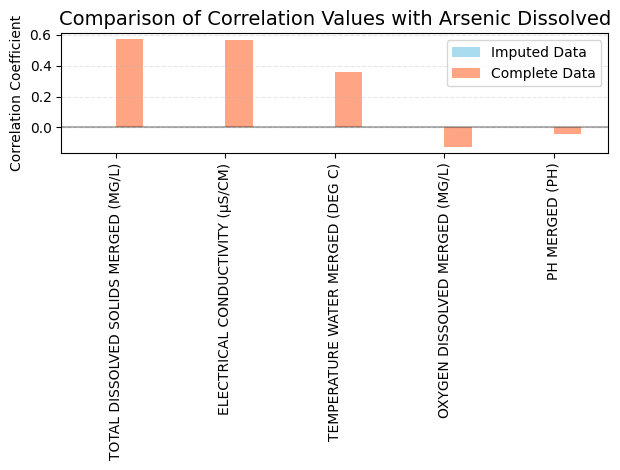

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv('new_combined_water_quality_dataset_fixed.csv', low_memory=False)

# Define target and features
target = 'ARSENIC DISSOLVED (µG/L)'
features = [
    'ELECTRICAL CONDUCTIVITY (µS/CM)',
    'PH MERGED (PH)',
    'TEMPERATURE WATER MERGED (DEG C)',
    'OXYGEN DISSOLVED MERGED (MG/L)',
    'TOTAL DISSOLVED SOLIDS MERGED (MG/L)'
]

# Create a subset with only the target and specified features
subset_df = df[[target] + features].copy()

# 1. CORRELATION MATRIX WITH IMPUTED VALUES
# =========================================

# Count missing values before imputation
missing_before = subset_df.isnull().sum()
print("Missing values before imputation:")
print(missing_before)
print(f"Total rows: {len(subset_df)}")

# Impute missing values using median
imputer = SimpleImputer(strategy='median')
imputed_data = imputer.fit_transform(subset_df)
imputed_df = pd.DataFrame(imputed_data, columns=subset_df.columns)

# Calculate correlation matrix on imputed data
imputed_corr = imputed_df.corr()

# Plot first correlation matrix (imputed data)
plt.figure(figsize=(10, 8))
sns.heatmap(
    imputed_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix with Imputed Data\n(All Rows, Missing Values Imputed)', fontsize=14)
plt.tight_layout()
plt.show()

# 2. CORRELATION MATRIX WITH COMPLETE ROWS ONLY
# ============================================

# Filter to keep only complete rows
complete_df = subset_df.dropna()

# Report how many rows remain
print(f"\nComplete rows (no missing values): {len(complete_df)} out of {len(subset_df)} ({len(complete_df)/len(subset_df)*100:.1f}%)")

# Calculate correlation matrix on complete data only
complete_corr = complete_df.corr()

# Plot second correlation matrix (complete data only)
plt.figure(figsize=(10, 8))
sns.heatmap(
    complete_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix with Complete Data\n(Only Rows with No Missing Values)', fontsize=14)
plt.tight_layout()
plt.show()

# 3. COMPARISON OF CORRELATION VALUES
# ==================================

# Display comparison of correlation values with arsenic dissolved
comparison = pd.DataFrame({
    'Imputed Data': imputed_corr[target].drop(target),
    'Complete Data': complete_corr[target].drop(target)
})

comparison['Difference'] = comparison['Complete Data'] - comparison['Imputed Data']
comparison = comparison.sort_values('Complete Data', key=abs, ascending=False)

print("\nComparison of correlation values with Arsenic Dissolved:")
print(comparison)

# Visualize the comparison
plt.figure(figsize=(12, 6))
comparison[['Imputed Data', 'Complete Data']].plot(
    kind='bar',
    color=['skyblue', 'coral'],
    alpha=0.7
)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.title('Comparison of Correlation Values with Arsenic Dissolved', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()